# Using autofe: propose features, validate them, loop

The worked example is the UCI [Taiwanese Bankruptcy](https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction) data: 6,819 companies, 95 financial ratios, 3.2% bankrupt. The incumbent model uses the profitability / leverage / growth ratios. The **cash-flow family** is a hand-declared candidate batch, with two planted controls - `cand_dup_roa_c`, a near-copy of an incumbent, and `cand_noise`, pure noise - so the screens have a known answer to find.

| Section | Covers |
| --- | --- |
| [1. Inputs](#1) | the materials a run needs, how to prepare them, and checking them |
| [2. Feature discovery](#2) | an LLM proposes candidates; each is screened on a small sample |
| [3. XGBoost validation](#3) | the five stages that decide which candidates earn a place |
| [4. The loop](#4) | keep what passed, propose again from the stronger incumbent set |

In [ ]:
# Re-import src/ modules whenever they change, so an edit to the package is picked
# up without restarting the kernel. Without it, a kernel that imported the old code
# keeps running it.
%load_ext autoreload
%autoreload 2

import json
import os
import sys
import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore", message="IProgress not found")   # tqdm, via shap

# The repo root, wherever this notebook is run from.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)   # config paths are relative to the repo root, as from the CLI

from validation import Pipeline, build_dataset, load_config

pd.set_option("display.width", 200, "display.max_columns", 40, "display.max_colwidth", 80)
CONFIG = "configs/bankruptcy.yaml"

<a id='1'></a>
## 1. Inputs

A run reads **materials prepared once** by the dataset's prepare notebook - `data/bankruptcy/prepare.ipynb` here, and `data/cdss_us_sbs/prepare.ipynb` is the template for a private dataset - plus **one config** that says how to use them. Nothing is split or sampled at run time: the three tables are read exactly as written.

| Material | Config key | Read by |
| --- | --- | --- |
| `train.csv` · `valid.csv` · `test.csv` | `data.paths` | every stage |
| `column_descriptions.json` | `discovery.column_descriptions_path` | discovery: what each column means |
| `few_shot.csv` | `discovery.few_shot_path` | discovery: the example rows the proposer sees |
| `screen_train.csv` · `screen_valid.csv` | `discovery.screen_paths` | discovery: the rows its screen fits and scores on |

What the config declares about them:

| Key | Here |
| --- | --- |
| `data.target` | `bankrupt` |
| `data.id_cols` | `row_id` - for the leakage check and the few-shot ids |
| `features.base` | empty, so every other numeric column is an incumbent |
| `features.new` | the cash-flow family and the two planted controls |
| `discovery.task_description` | what the data is, in domain terms - the proposer's only briefing |

### Preparing the materials

Each dataset gets a prepare notebook that writes its materials once, before any run: `data/bankruptcy/prepare.ipynb` is the full worked example, and `data/cdss_us_sbs/prepare.ipynb` the template for data that arrives already split. The steps are always the same six. Here they run on the bankruptcy archive, condensed, and write to `outputs/usage_materials/` so the demo's own files are left alone.

| Step | Writes | Read by |
| --- | --- | --- |
| 1. one table, readable names | - | - |
| 2. split once | - | - |
| 3. check against the config, write | `train.csv` · `valid.csv` · `test.csv`, `column_mapping.csv`, `column_descriptions.json` | every stage; discovery's prompt |
| 4. few-shot rows | `few_shot.csv` | discovery's prompt |
| 5. screen samples | `screen_train.csv` · `screen_valid.csv` | discovery's screen |
| 6. point the config at them | - | - |

The paths come from the config, so the notebook and the pipeline never disagree about where a file lives. For this draft they are redirected to the scratch folder:

In [2]:
from preprocessing import (build_sample, build_shot_batches, fetch_archive, sanitize_columns,
                           stratified_split, write_splits)
from validation.data import resolve_features

WORK = ROOT / "outputs" / "usage_materials"
cfg_prep = load_config(CONFIG, {
    "data.paths": {part: str(WORK / f"{part}.csv") for part in ("train", "valid", "test")},
    "discovery.few_shot_path": str(WORK / "few_shot.csv"),
    "discovery.screen_paths": {part: str(WORK / f"screen_{part}.csv") for part in ("train", "valid")},
    "discovery.column_descriptions_path": str(WORK / "column_descriptions.json"),
})
# The demo's two planted controls are built by its prepare notebook; this draft
# keeps the cash-flow family, the columns the archive really has.
cfg_prep.features.new = [c for c in cfg_prep.features.new if not c.startswith("cand_")]
target, id_col = cfg_prep.data.target, cfg_prep.data.id_cols[0]

**1. One table, readable names.** Load the source and sanitize its headers to snake_case, so they survive YAML, CSV and generated code. `mapping` keeps the originals - by default they become the column descriptions. Add a row id: the leakage check and the sample files key on it.

In [3]:
URL = "https://archive.ics.uci.edu/static/public/572/taiwanese+bankruptcy+prediction.zip"
raw = pd.read_csv(fetch_archive(URL, ROOT / "data" / "bankruptcy" / "raw" / "uci572", "data.csv"))

table, mapping = sanitize_columns(raw)
table.insert(0, id_col, range(len(table)))
print(f"{table.shape[0]:,} rows x {table.shape[1]} columns; target {target!r} is "
      f"{table[target].mean():.2%} positive")
mapping.head(3)

6,819 rows x 97 columns; target 'bankrupt' is 3.23% positive


,original,column
0,Bankrupt?,bankrupt
1,ROA(C) before interest and depreciation before interest,roa_c_before_interest_and_depreciation_before_interest
2,ROA(A) before interest and % after tax,roa_a_before_interest_and_pct_after_tax


**2. Split once.** Stratified on the target with a fixed seed, so every part keeps the base rate. This is the only split anywhere: the pipeline reads the three tables as written. Skip this step when the data arrives split - start from the three extracts instead.

In [4]:
splits = stratified_split(table, target, valid_size=0.2, test_size=0.2, seed=42)
{part: f"{len(rows):,} rows, {rows[target].mean():.2%} positive" for part, rows in splits.items()}

{'train': '4,091 rows, 3.23% positive',
 'valid': '1,364 rows, 3.23% positive',
 'test': '1,364 rows, 3.23% positive'}

**3. Check against the config, write.** `write_splits` refuses to write anything the pipeline would later misread: a target that is not 0/1, a declared candidate the table does not have, or an id that appears in two splits (leakage). Then it writes the three tables to `data.paths`, with `column_mapping.csv` (sanitized name -> original) and `column_descriptions.json` (each column's original header, unless you pass your own descriptions).

In [5]:
written = write_splits(cfg_prep, splits, root=ROOT, mapping=mapping)
for name, path in written.items():
    print(f"{name:<13} {path.name}")

train         train.csv
valid         valid.csv
test          test.csv
descriptions  column_descriptions.json
mapping       column_mapping.csv


**4. Few-shot rows.** The only concrete data the proposer ever sees: per class, one representative row per KMeans cluster of train's incumbent columns, 16 per class, in 10 batches. Batch *r* is shown in round *r*, and the rotation continues across runs. Saved as full rows - `train.csv`'s columns plus `batch`.

In [6]:
base, _ = resolve_features(splits["train"], cfg_prep.features, cfg_prep.data)
batches = build_shot_batches(splits["train"], target, columns=base, shots=32, batches=10, seed=42)
shots = pd.concat([b.assign(batch=i) for i, b in enumerate(batches)], ignore_index=True)
shots = shots[["batch", *splits["train"].columns]]
shots.to_csv(cfg_prep.discovery.few_shot_path, index=False)
print(f"{len(batches)} batches x {len(batches[0])} rows, "
      f"{int(shots.query('batch == 0')[target].sum())} positive in batch 0")

10 batches x 32 rows, 16 positive in batch 0


**5. Screen samples.** What discovery's screen fits each proposal on (a sample of train) and scores it on (a sample of valid). Class-balanced here: each class contributes up to half the rows, so every bankruptcy is kept instead of the few dozen a uniform draw would give. Saved in the same format as the splits. To keep valid independent of the proposer's feedback, draw both samples from disjoint rows of train instead; or set `discovery.screen_data: splits` to screen on the whole splits and skip this step.

In [7]:
screen = {part: build_sample(splits[part], target, size, balance=True, seed=42)
          for part, size in (("train", 1500), ("valid", 600))}
for part, rows in screen.items():
    rows.to_csv(cfg_prep.discovery.screen_paths[part], index=False)
{part: f"{len(rows):,} rows, {int(rows[target].sum())} positive" for part, rows in screen.items()}

{'train': '882 rows, 132 positive', 'valid': '344 rows, 44 positive'}

**6. Point the config at them.** For a new dataset, these are the keys that name the materials and say how to read them - `configs/cdss_us_sbs.yaml` is a filled-in template:

```yaml
data:
  paths: {train: data/<name>/train.csv, valid: data/<name>/valid.csv, test: data/<name>/test.csv}
  target: <the 0/1 outcome column>
  id_cols: [<the row id>]
  missing_values: [-9999]            # sentinel codes, if the source has any
features:
  base: []                           # empty: every other numeric column is an incumbent
  new: [<the candidates>]
discovery:
  task_description: <what a row is, the population, what the target means>
  column_descriptions_path: data/<name>/column_descriptions.json
  few_shot_path: data/<name>/few_shot.csv
  screen_data: files
  screen_paths: {train: data/<name>/screen_train.csv, valid: data/<name>/screen_valid.csv}
  history_path: outputs/discovery_history/<name>.csv
```

A last check that the pipeline reads what was written:

In [8]:
print(build_dataset(cfg_prep).describe())

{'rows_per_split': {'train': 4091, 'valid': 1364, 'test': 1364}, 'n_base_features': 84, 'n_new_features': 11, 'target': 'bankrupt'}


### Checking the demo's materials

The same materials for the bankruptcy demo were written by `data/bankruptcy/prepare.ipynb`. Every path below comes from `configs/bankruptcy.yaml`:

In [9]:
cfg = load_config(CONFIG)
materials = {
    **{f"data.paths.{name}": path for name, path in cfg.data.paths.items()},
    "discovery.column_descriptions_path": cfg.discovery.column_descriptions_path,
    "discovery.few_shot_path": cfg.discovery.few_shot_path,
    **{f"discovery.screen_paths.{name}": path for name, path in cfg.discovery.screen_paths.items()},
}
for key, path in materials.items():
    status = "ok" if Path(path).exists() else "MISSING - run data/bankruptcy/prepare.ipynb"
    print(f"{key:<36} {path:<46} {status}")

data.paths.train                     data/bankruptcy/train.csv                      ok
data.paths.valid                     data/bankruptcy/valid.csv                      ok
data.paths.test                      data/bankruptcy/test.csv                       ok
discovery.column_descriptions_path   data/bankruptcy/column_descriptions.json       ok
discovery.few_shot_path              data/bankruptcy/few_shot.csv                   ok
discovery.screen_paths.train         data/bankruptcy/screen_train.csv               ok
discovery.screen_paths.valid         data/bankruptcy/screen_valid.csv               ok


In [10]:
dataset = build_dataset(cfg)
print(dataset.describe())
print("declared candidates:", dataset.new_features)

{'rows_per_split': {'train': 4091, 'valid': 1364, 'test': 1364}, 'n_base_features': 84, 'n_new_features': 13, 'target': 'bankrupt'}
declared candidates: ['cash_flow_rate', 'cash_flow_per_share', 'cash_reinvestment_pct', 'cash_total_assets', 'cash_current_liability', 'cash_turnover_rate', 'cash_flow_to_sales', 'cash_flow_to_total_assets', 'cash_flow_to_liability', 'cfo_to_assets', 'cash_flow_to_equity', 'cand_dup_roa_c', 'cand_noise']


In [11]:
descriptions = json.loads(Path(cfg.discovery.column_descriptions_path).read_text())
few_shot = pd.read_csv(cfg.discovery.few_shot_path)

print(f"{len(descriptions)} column descriptions, e.g.")
for column in dataset.base_features[:3]:
    print(f"  {column:<56} {descriptions.get(column, '(none)')}")
first = few_shot.query("batch == 0")
print(f"\nfew-shot rows: {few_shot['batch'].nunique()} batches of {len(first)}; "
      f"batch 0 holds {int(first[cfg.data.target].sum())} bankrupt companies")

97 column descriptions, e.g.
  roa_c_before_interest_and_depreciation_before_interest   ROA(C) before interest and depreciation before interest
  roa_a_before_interest_and_pct_after_tax                  ROA(A) before interest and % after tax
  roa_b_before_interest_and_depreciation_after_tax         ROA(B) before interest and depreciation after tax

few-shot rows: 10 batches of 32; batch 0 holds 16 bankrupt companies


<a id='2'></a>
## 2. Feature discovery

An LLM reads the task description and every incumbent column - its description and its values in the few-shot rows - and proposes a batch of new columns as pandas code. Each proposal runs in a sandbox and is **screened**: an XGBoost model with and without it, fitted on a sample of train and scored on a sample of valid. The screen is cheap and noisy by design; it gives the proposer feedback each round, while the decision is section 3's, on the full splits.

The knobs, under `discovery:` in the config:

| Key | Here | What it does |
| --- | --- | --- |
| `strategy` | `caafe` | how the LLM is asked: `caafe`, `elfgym`, `ferg`, `featllm` or `promptfe` |
| `batch_size` | 5 | proposals per round |
| `max_rounds` | 2 | rounds; each one sees every earlier proposal and its screen score |
| `screen_data` | `files` | what the screen fits and scores on: `splits` (the whole train and valid splits) or `files` (rows the prepare notebook sampled from them) |
| `screen_paths` | `screen_train.csv`, `screen_valid.csv` | those samples, in the same format as the splits - class-balanced here, since 3% positives would leave almost none |
| `history_path` | `outputs/discovery_history/bankruptcy.csv` | every earlier proposal with its verdict and the reason, read into the prompt; round numbers and the few-shot rotation continue from it |
| `llm.model` | `gpt-4o` | which model proposes |

Scoring on valid means the proposer's feedback comes from valid rows, so valid stops being an independent check on the features it proposes; test still is.

In [12]:
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv(usecwd=True))
assert os.environ.get("OPENAI_API_KEY"), (
    "OPENAI_API_KEY is not set: put it in .env at the repo root, or export it")
print("LLM credential found")

LLM credential found


In [13]:
from discovery.stage import run_discovery_stage

cfg_discovery = load_config(CONFIG, {"discovery.enabled": True})
discovered = run_discovery_stage(cfg_discovery, dataset,
                                 output_dir=ROOT / "outputs" / "usage_discovery")
print(json.dumps(discovered.summary(), indent=2))

model.params sets colsample_bytree < 1: base and leave_one_in variants differ in column count, so their gini gain includes an offset unrelated to any feature (a constant column measured -0.0055 on this data). The screen strips it for its own delta; set these to 1.0 to remove it from the verdict too.


{
  "enabled": true,
  "proposed": 10,
  "kept": 4,
  "kept_features": [
    "profit_margin_variability",
    "asset_utilization_efficiency",
    "debt_to_asset_utilization_ratio",
    "growth_vs_profitability"
  ],
  "rounds": 2,
  "stopped_because": "max_rounds reached (2)",
  "screen_base_score": 0.8566666666666667
}


In [14]:
ledger = discovered.to_frame()
ledger[["round", "feature_name", "rationale", "input_columns", "delta", "error"]].round(4)

,round,feature_name,rationale,input_columns,delta,error
0,1,profit_margin_variability,Identifies companies with high operating efficiency but low net profit reten...,"operating_profit_per_person, net_income_to_total_assets, net_worth_assets",0.0074,None
1,1,liquidity_stress,"Identifying companies that might have higher risk of liquidity issues, relev...","quick_ratio, current_ratio",NaN,Generated feature 'liquidity_stress' spikes on the sample data: largest magn...
2,1,asset_utilization_efficiency,Finds companies that grow their assets but may struggle to turn them into re...,"total_asset_turnover, total_asset_growth_rate",-0.0102,None
3,1,leverage_effect_variance,"Helps to assess the impact of leverage on profitability, which is critical i...","interest_expense_ratio, roa_a_before_interest_and_pct_after_tax, net_value_g...",NaN,Generated feature 'leverage_effect_variance' spikes on the sample data: larg...
4,1,capital_intensity_ratio,Highlights companies that may face constraints in managing operational scale...,"fixed_assets_to_assets, equity_to_liability",NaN,Generated feature 'capital_intensity_ratio' spikes on the sample data: large...
5,2,financial_stability_index,Provides a holistic view of a company's financial health by combining key in...,"liability_to_equity, net_worth_assets, current_ratio",NaN,Generated feature 'financial_stability_index' has 1 infinite or non-numeric ...
6,2,profitability_efficiency_ratio,Identifies companies that are good at converting revenues into actual profit...,"net_income_to_total_assets, total_asset_turnover",NaN,Generated feature 'profitability_efficiency_ratio' is redundant: |rho|=0.994...
7,2,debt_to_asset_utilization_ratio,Helps assess the risk posed by debt in regard to a company's ability to util...,"debt_ratio_pct, total_asset_turnover",-0.0002,None
8,2,cash_conversion_capability,It identifies companies that are capable or incapable of managing their inve...,"inventory_turnover_rate_times, current_ratio",NaN,Generated feature 'cash_conversion_capability' is redundant: |rho|=0.934 aga...
9,2,growth_vs_profitability,Evaluates if a company is growing its assets at the expense of profitability...,"total_asset_growth_rate, roa_a_before_interest_and_pct_after_tax",0.0088,None


In [15]:
ran = ledger[ledger["error"].isna()]
print(ran.iloc[0]["code"] if len(ran) else "no proposal ran cleanly")

widened = discovered.dataset
print(f"\ncandidates now: {len(widened.new_features)} = {len(dataset.new_features)} declared "
      f"+ {len(discovered.kept_features)} discovered")

# (profit_margin_variability, Measures the difference between operating and net profit margins)
# Usefulness: Identifies companies with high operating efficiency but low net profit retention, useful for detecting potential financial distress.
# Input samples: 'df["operating_profit_per_person"]': [0.39, 0.399, 0.393], 'df["net_income_to_total_assets"]': [0.758, 0.812, 0.809]
df["profit_margin_variability"] = df["operating_profit_per_person"] - (df["net_income_to_total_assets"] * df["net_worth_assets"])

candidates now: 17 = 13 declared + 4 discovered


<a id='3'></a>
## 3. XGBoost validation

Every candidate - declared and discovered alike - goes through the same five stages, on the full splits:

| Stage | Question | Config |
| --- | --- | --- |
| 1. data quality | is the column usable, and shaped the same in valid / test as in train? | `data_quality.*` |
| 2. feature selection | does it carry signal the incumbents do not already carry? | `feature_selection.*` |
| 3. model builds | XGBoost `base`, `base_plus_new`, and `leave_one_in` - the incumbents plus one candidate | `model.*` |
| 4. analysis | Gini gain per variant on valid and test; SHAP rank | `analysis.*` |
| 5. verdict | four gates per candidate, then KEEP or TRY A NEW BATCH for the batch | `verdict.*` |

The widened dataset from section 2 is passed straight in, so discovery does not run again. From the command line, sections 2 and 3 are one run: `autofe -c configs/bankruptcy.yaml --set discovery.enabled=true`.

In [16]:
cfg_validate = load_config(CONFIG, {"run.name": "usage_validation", "run.log_level": "WARNING"})
result = Pipeline(cfg_validate).run(dataset=widened)
print(f"{result.elapsed_seconds:.0f}s -> {result.output_dir}")

57s -> outputs/usage_validation/20260915_224947


### The verdict

Four gates per candidate. `run.gates: open` measures every candidate at every gate and removes nothing, so the table shows where each one would have fallen; `enforce` makes the gates act.

| Gate | Fails when | Threshold |
| --- | --- | --- |
| `data quality` | the column itself is unusable | `data_quality.*` |
| `feature selection` | no signal, or signal the incumbents already carry | `feature_selection.*` |
| `gini gain` | its `leave_one_in` model did not beat `base` on test and valid | `verdict.min_gini_gain` |
| `shap rank` | the model kept it but barely uses it | `verdict.max_shap_rank_pct` |

In [17]:
gate_cols = ["feature", "verdict", "failed_at", "data quality", "feature selection","gini gain", "shap rank", "gini_gain_test", "reason"]
verdicts = result.verdicts[gate_cols].copy()
verdicts.insert(1, "source", ["discovered" if f in discovered.kept_features else "declared"
                              for f in verdicts["feature"]])
verdicts.round(4)

,feature,source,verdict,failed_at,data quality,feature selection,gini gain,shap rank,gini_gain_test,reason
0,cash_turnover_rate,declared,FAIL,feature selection,PASS,FAIL,FAIL,PASS,0.0178,signal screen: weak spearman vs target (0.0172) | gini gain +0.0178 on test ...
1,cash_total_assets,declared,FAIL,gini gain,PASS,PASS,FAIL,PASS,0.0175,"gini gain +0.0175 on test (valid -0.0066), below +0.0050"
2,debt_to_asset_utilization_ratio,discovered,FAIL,gini gain,PASS,PASS,FAIL,PASS,0.0113,"gini gain +0.0113 on test (valid -0.0008), below +0.0050"
3,cash_flow_to_total_assets,declared,FAIL,feature selection,PASS,FAIL,FAIL,PASS,0.0111,redundancy screen: redundant with cash_flow_to_sales (|rho|=0.971) | gini ga...
4,cash_flow_to_equity,declared,FAIL,feature selection,PASS,FAIL,FAIL,FAIL,0.0108,redundancy screen: redundant with cash_flow_to_sales (|rho|=0.955) | gini ga...
5,cand_noise,declared,FAIL,feature selection,PASS,FAIL,FAIL,FAIL,0.0105,signal screen: weak spearman vs target (-0.0066) | gini gain +0.0105 on test...
6,cash_current_liability,declared,FAIL,gini gain,PASS,PASS,FAIL,PASS,0.0105,"gini gain +0.0105 on test (valid -0.0035), below +0.0050"
7,cfo_to_assets,declared,FAIL,feature selection,PASS,FAIL,FAIL,FAIL,0.0102,redundancy screen: redundant with cash_flow_per_share (|rho|=0.954) | gini g...
8,cand_dup_roa_c,declared,FAIL,feature selection,PASS,FAIL,FAIL,PASS,0.0095,redundancy screen: redundant with roa_c_before_interest_and_depreciation_bef...
9,profit_margin_variability,discovered,FAIL,gini gain,PASS,PASS,FAIL,PASS,0.0092,"gini gain +0.0092 on test (valid -0.0045), below +0.0050"


In [18]:
print(json.dumps(result.batch.summary(), indent=2))

{
  "verdict": "TRY A NEW BATCH",
  "n_candidates": 17,
  "n_passed": 0,
  "passed": [],
  "failed_at": {
    "feature selection": 10,
    "gini gain": 7
  },
  "batch_gini_gain": 0.0207,
  "note": "No candidate cleared all four gates - most fell at the feature selection. Propose a different batch rather than relaxing the thresholds. Gates are OPEN (run.gates: open): this is advisory only - nothing was removed, and every candidate was measured at all four gates."
}


In [19]:
cols = ["variant", "n_features", "adj_gini_valid", "adj_gini_test", "gini_gain_valid", "gini_gain_test"]
result.analysis.comparison[cols].sort_values("gini_gain_test", ascending=False).round(4).head(12)

,variant,n_features,adj_gini_valid,adj_gini_test,gini_gain_valid,gini_gain_test
1,base_plus_new,101,0.9184,0.9062,-0.0042,0.0207
14,loi__cash_turnover_rate,85,0.9072,0.9033,-0.0154,0.0178
13,loi__cash_total_assets,85,0.9160,0.9030,-0.0066,0.0175
16,loi__debt_to_asset_utilization_ratio,85,0.9218,0.8968,-0.0008,0.0113
11,loi__cash_flow_to_total_assets,85,0.9036,0.8966,-0.0190,0.0111
8,loi__cash_flow_to_equity,85,0.9180,0.8962,-0.0046,0.0108
4,loi__cand_noise,85,0.9180,0.8960,-0.0045,0.0105
5,loi__cash_current_liability,85,0.9191,0.8959,-0.0035,0.0105
15,loi__cfo_to_assets,85,0.9225,0.8956,-0.0001,0.0102
3,loi__cand_dup_roa_c,85,0.9156,0.8949,-0.0070,0.0095


#### Adjusted Gini per variant, against base

The same comparison, drawn: every variant's adjusted Gini on valid (left) and on test (right). The vertical line in each panel is `base` on that split, so a stem to the right of it beats the incumbents there and a stem to the left loses to them. Both panels share one scale, so stems of the same length are the same change. Each `loi__` row is base plus one candidate; the planted `cand_` controls should sit on the line.

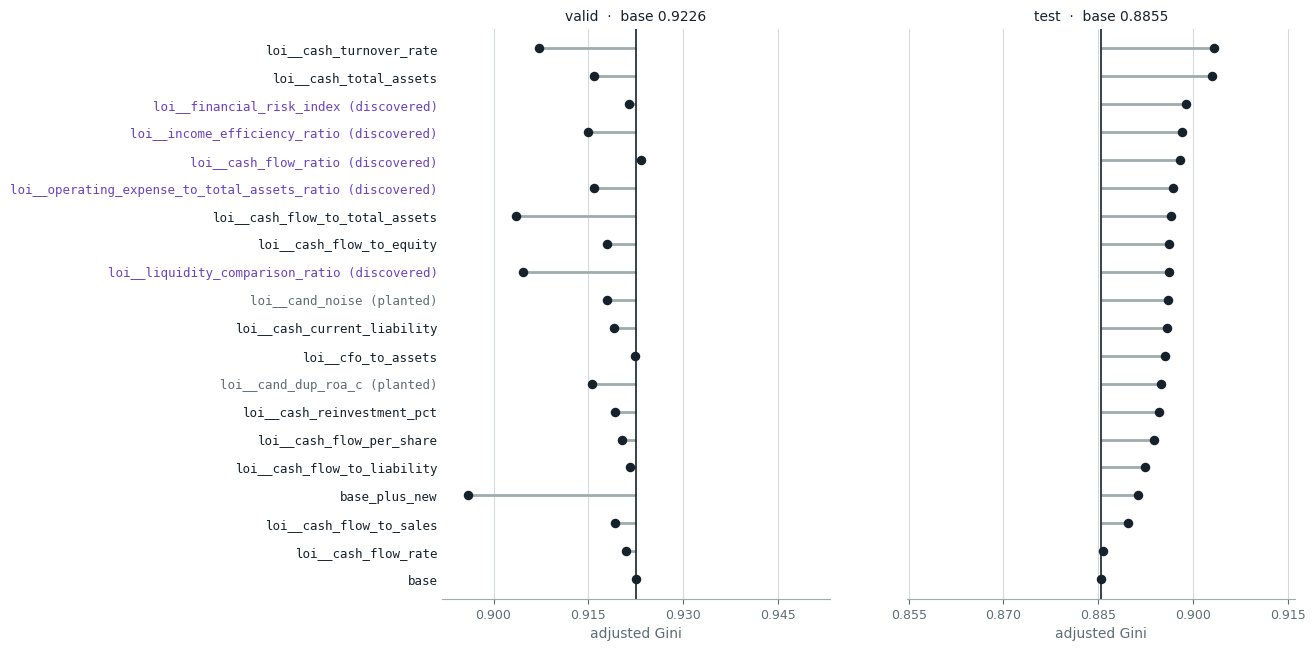

In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Each variant's adjusted Gini on valid and on test, against base on the same split:
# a stem right of the line beats the incumbents there, a stem left of it loses.
splits = ["valid", "test"]
gini = (result.analysis.comparison.set_index("variant")
        [[f"adj_gini_{split}" for split in splits]]
        .set_axis(splits, axis=1)
        .sort_values("test"))                  # plotted bottom-up, so the best test Gini is on top
base = gini.loc["base"]
# One scale for both panels, centred on each split's base, so equal stems are equal changes.
span = (gini - base).abs().to_numpy().max() * 1.15

INK, MUTED, LINE, GRID, NEW = "#15212B", "#5E6D74", "#9EACAC", "#D3DBD9", "#6C42BD"

def label(variant):
    feature = variant.removeprefix("loi__")
    if feature.startswith("cand_"):
        return f"{variant} (planted)", MUTED
    if feature in discovered.kept_features:
        return f"{variant} (discovered)", NEW
    return variant, INK

rows = range(len(gini))
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(11, 0.3 * len(gini) + 1.4))
for ax, split in zip(axes, splits):
    ax.hlines(rows, base[split], gini[split], color=LINE, lw=2, zorder=1)
    ax.scatter(gini[split], rows, s=34, color=INK, zorder=3)
    ax.axvline(base[split], color=INK, lw=1.2, zorder=2)
    ax.set_title(f"{split}  ·  base {base[split]:.4f}", fontsize=10, color=INK)
    ax.set_xlim(base[split] - span, base[split] + span)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:.3f}")
    ax.grid(axis="x", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", colors=MUTED, labelsize=9)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(LINE)
    ax.set_xlabel("adjusted Gini", color=MUTED)

labels = [label(v) for v in gini.index]
axes[0].set_yticks(list(rows), [text for text, _ in labels], family="monospace", fontsize=9)
for tick, (_, color) in zip(axes[0].get_yticklabels(), labels):
    tick.set_color(color)
axes[0].set_ylim(-0.7, len(gini) - 0.3)
plt.show()

In [21]:
# Where the candidates land in the base_plus_new model's SHAP ranking.
ranking = result.analysis.feature_ranking.query("variant == 'base_plus_new'")
ranking[ranking["feature"].isin(result.dataset.new_features)][
    ["feature", "mean_abs_shap", "shap_share", "shap_rank"]].round(4)

,feature,mean_abs_shap,shap_share,shap_rank
84,profit_margin_variability,0.4907,0.0955,1
97,cash_flow_per_share,0.0930,0.0181,14
104,debt_to_asset_utilization_ratio,0.0753,0.0146,21
106,cash_flow_to_sales,0.0619,0.0120,23
108,cash_flow_to_total_assets,0.0552,0.0107,25
109,cash_turnover_rate,0.0542,0.0105,26
111,cash_total_assets,0.0479,0.0093,28
126,cash_current_liability,0.0329,0.0064,43
128,cand_dup_roa_c,0.0299,0.0058,45
130,cash_reinvestment_pct,0.0275,0.0054,47


#### One feature at a time: SHAP rank in its base + one model

The table above ranks the candidates inside `base_plus_new`, where they compete with each other as well as with the incumbents - a candidate can take credit that would otherwise go to a correlated one. Each candidate also has its own `leave_one_in` model, `loi__<feature>`: the incumbents plus that one feature. Its rank there is the cleanest read of how much the model uses it when nothing else new is present.

`rank_pct` is the rank as a fraction of the model's features. `ratio` is its SHAP share against an equal split - 1.0 means it pulls exactly its headcount weight. Each row comes from a different model, so `mean_abs_shap` is on that model's own scale: compare rows by `rank_pct` or `ratio`, not by raw SHAP. `gini_gain_test` is the same model's gain over `base`, shown alongside because attribution is not value. The verdict's SHAP gate reads `verdict.shap_variant` (`base_plus_new` here); this is the per-feature view.

In [22]:
comparison = result.analysis.comparison.set_index("variant")
rows = []
for feature in result.dataset.new_features:
    variant = f"loi__{feature}"
    shap = result.analysis.shap_ranking.query("variant == @variant")
    if feature not in set(shap["feature"]):
        continue          # no base + one model for it
    row = shap.set_index("feature").loc[feature]
    rows.append({
        "feature": feature,
        "source": "discovered" if feature in discovered.kept_features else "declared",
        "shap_rank": int(row["shap_rank"]),
        "of": len(shap),
        "rank_pct": row["shap_rank"] / len(shap),
        "mean_abs_shap": row["mean_abs_shap"],
        "shap_share": row["shap_share"],
        "ratio": row["shap_share"] * len(shap),
        "gini_gain_test": comparison.loc[variant, "gini_gain_test"],
    })

pd.DataFrame(rows).sort_values("shap_rank").reset_index(drop=True).round(4)

,feature,source,shap_rank,of,rank_pct,mean_abs_shap,shap_share,ratio,gini_gain_test
0,profit_margin_variability,discovered,1,85,0.0118,0.4880,0.0911,7.7451,0.0092
1,cash_flow_to_sales,declared,8,85,0.0941,0.1894,0.0292,2.4839,0.0043
2,cash_flow_per_share,declared,9,85,0.1059,0.1572,0.0298,2.5306,0.0084
3,cash_flow_rate,declared,12,85,0.1412,0.1476,0.0222,1.8872,0.0002
4,cash_flow_to_equity,declared,12,85,0.1412,0.1273,0.0260,2.2088,0.0108
5,cash_flow_to_liability,declared,12,85,0.1412,0.1583,0.0249,2.1183,0.0070
6,cfo_to_assets,declared,14,85,0.1647,0.1230,0.0228,1.9361,0.0102
7,cash_flow_to_total_assets,declared,16,85,0.1882,0.0157,0.0165,1.4033,0.0111
8,cash_total_assets,declared,18,85,0.2118,0.0810,0.0201,1.7056,0.0175
9,cash_reinvestment_pct,declared,23,85,0.2706,0.0587,0.0112,0.9559,0.0091


In [23]:
# Everything the run wrote; report.md is the human-readable summary.
for path in sorted(result.output_dir.rglob("*")):
    if path.is_file():
        print(path.relative_to(result.output_dir))

batch_verdict.json
candidate_verdicts.csv
config.resolved.yaml
data_quality_report.csv
feature_ranking.csv
feature_selection_decisions.json
feature_selection_mi_matrix.csv
feature_selection_redundancy.csv
feature_selection_spearman_matrix.csv
feature_selection_target_stats.csv
feature_selection_verdicts.csv
metrics_by_variant_split.csv
models/base.json
models/base_plus_new.json
models/loi__asset_utilization_efficiency.json
models/loi__cand_dup_roa_c.json
models/loi__cand_noise.json
models/loi__cash_current_liability.json
models/loi__cash_flow_per_share.json
models/loi__cash_flow_rate.json
models/loi__cash_flow_to_equity.json
models/loi__cash_flow_to_liability.json
models/loi__cash_flow_to_sales.json
models/loi__cash_flow_to_total_assets.json
models/loi__cash_reinvestment_pct.json
models/loi__cash_total_assets.json
models/loi__cash_turnover_rate.json
models/loi__cfo_to_assets.json
models/loi__debt_to_asset_utilization_ratio.json
models/loi__growth_vs_profitability.json
models/loi__profi

<a id='4'></a>
## 4. The loop

One pass answers one question - did this batch earn a place? The loop keeps asking, and three things carry from one iteration to the next:

- **The incumbent set never changes.** Every proposal is judged the same way: base vs base plus that one feature (`leave_one_in`). A feature that clears every gate is **accepted as a candidate** - there are still steps before it can join a model - so each new batch is judged against the same base, not a moving one.
- **The history.** `discovery.history_path` records every proposal with its outcome and the reason: accepted, rejected at a gate and why, or rejected by the screen. Each run reads it into the prompt, so the proposer does not repeat an idea already judged, and appends its own proposals once the verdict is in.
- **The example rows keep rotating.** Round numbers continue across runs and round *r* shows few-shot batch *r*, cycling through all ten - so a new run never restarts at rows the proposer has already seen.

It stops after `MAX_ITERATIONS`, or after `PATIENCE` iterations in a row that accepted nothing.

In [24]:
MAX_ITERATIONS, PATIENCE = 3, 2

history_path = ROOT / "outputs" / "usage_loop_history.csv"
history_path.unlink(missing_ok=True)                            # a fresh study for this notebook
base_only = dataset.with_features(dataset.base_features, [])   # only what the proposer brings

accepted, misses = [], 0
for iteration in range(1, MAX_ITERATIONS + 1):
    cfg_loop = load_config(CONFIG, {"run.name": f"usage_loop_{iteration}", "run.log_level": "WARNING",
                                    "discovery.enabled": True,
                                    "discovery.history_path": str(history_path)})
    run = Pipeline(cfg_loop).run(dataset=base_only)
    passed = list(run.batch.passed)
    accepted += passed
    print(f"iteration {iteration}: {run.batch.verdict} - {len(passed)} of "
          f"{run.batch.n_candidates} accepted{': ' + ', '.join(passed) if passed else ''}")
    misses = 0 if passed else misses + 1
    if misses >= PATIENCE:
        print(f"stopping: {PATIENCE} iteration(s) in a row accepted nothing")
        break

print(f"\naccepted candidates, each judged base vs base + it: {accepted or 'none'}")

2026-09-15 22:50:46,582 | WARNING | discovery.stage              | model.params sets colsample_bytree < 1: base and leave_one_in variants differ in column count, so their gini gain includes an offset unrelated to any feature (a constant column measured -0.0055 on this data). The screen strips it for its own delta; set these to 1.0 to remove it from the verdict too.


2026-09-15 22:51:06,539 | WARNING | validation.pipeline          | no new features survived selection; only the baseline will be informative


iteration 1: TRY A NEW BATCH - 0 of 0 accepted
2026-09-15 22:51:13,711 | WARNING | discovery.stage              | model.params sets colsample_bytree < 1: base and leave_one_in variants differ in column count, so their gini gain includes an offset unrelated to any feature (a constant column measured -0.0055 on this data). The screen strips it for its own delta; set these to 1.0 to remove it from the verdict too.


2026-09-15 22:52:01,387 | WARNING | discovery.stage              | discovery: dropping 'revenue_diversity_index' - it passed the screen but fails on the full splits: Generated feature 'revenue_diversity_index' spikes on the train data: largest magnitude 1.16825e+10 is 585227074x its 99th percentile (19.9623), at row 1421. This is the signature of a division guarded with a tiny epsilon: adding 1e-6 to a zero denominator does not prevent a blow-up, it produces a value of order 1e6, which destroys the fit. Keep the result on a scale comparable to its inputs - mask the invalid rows, use a denominator that cannot approach zero, or clip the result.


iteration 2: TRY A NEW BATCH - 0 of 2 accepted
stopping: 2 iteration(s) in a row accepted nothing

accepted candidates, each judged base vs base + it: none


The history the loop built - every proposal, what became of it, and why:

In [25]:
history = pd.read_csv(history_path)
history[["run", "round", "feature_name", "outcome", "failed_at", "reason"]]

,run,round,feature_name,outcome,failed_at,reason
0,usage_loop_1/20260915_225046,1,asset_liability_contrast,rejected,screen,Generated feature 'asset_liability_contrast' is redundant: |rho|=0.983 again...
1,usage_loop_1/20260915_225046,1,persistent_to_quick_ratio,rejected,screen,Generated feature 'persistent_to_quick_ratio' is redundant: |rho|=0.961 agai...
2,usage_loop_1/20260915_225046,1,profitability_and_liquidity_interplay,rejected,screen,Generated feature 'profitability_and_liquidity_interplay' spikes on the samp...
3,usage_loop_1/20260915_225046,1,investment_efficiency_ratio,rejected,screen,Generated feature 'investment_efficiency_ratio' is redundant: |rho|=0.966 ag...
4,usage_loop_1/20260915_225046,1,growth_vs_turnover,rejected,screen,Generated feature 'growth_vs_turnover' is redundant: |rho|=0.996 against the...
5,usage_loop_1/20260915_225046,2,profit_leverage_interaction,rejected,screen,Generated feature 'profit_leverage_interaction' is redundant: |rho|=0.905 ag...
6,usage_loop_1/20260915_225046,2,liquidity_vs_operation,rejected,screen,Generated feature 'liquidity_vs_operation' spikes on the sample data: larges...
7,usage_loop_1/20260915_225046,2,earnings_to_debt_stability,rejected,screen,Generated feature 'earnings_to_debt_stability' is redundant: |rho|=0.990 aga...
8,usage_loop_1/20260915_225046,2,cash_flow_effectiveness,rejected,screen,Generated feature 'cash_flow_effectiveness' is redundant: |rho|=0.997 agains...
9,usage_loop_1/20260915_225046,2,equity_impact_factor,rejected,screen,Generated feature 'equity_impact_factor' is redundant: |rho|=0.924 against t...


And how the next iteration's proposer reads it - the same records, as they appear in its prompt:

In [26]:
from discovery.prompt import format_history

records = history.astype(object).where(history.notna(), None).to_dict("records")
print(format_history(records[-2:], "adjusted Gini"))

Previous code block 4:
```python
# (sustainability_equity_ratio, Equity sustainability measured by operating profits)
# Usefulness: Indicates how sustainable equity levels are against operating profit levels, offering insights into profit contributions to equity stability.
# Input samples: 'df["operating_profit_per_person"]': [0.397, 0.395, 0.393], 'df["current_liabilities_equity"]': [0.328, 0.331, 0.33]
df["sustainability_equity_ratio"] = df["operating_profit_per_person"] / df["current_liabilities_equity"].where(df["current_liabilities_equity"] != 0, np.nan)
```end
Score without the feature (adjusted Gini): 0.8567
Score with the feature (adjusted Gini): 0.8520
Change (adjusted Gini): -0.0047
Validated on the full data: REJECTED at the gini gain gate - gini gain +0.0107 on test (valid -0.0179), below +0.0050. Do not repeat this idea; propose something that avoids the reason it failed. It is not present in `df` for later blocks: every block starts from the same original columns.

Previo

Each iteration writes a full run directory under `outputs/usage_loop_<n>/`: `discovered_features.csv` is that iteration's proposals, and `report.md` its verdict. The accepted candidates are the loop's output - each passed base vs base + it on its own, and the steps that decide whether they enter a model come after.

**Before acting on an accepted candidate.** The thresholds live in the config (`verdict.min_gini_gain`, `verdict.require_valid_too`, `verdict.max_shap_rank_pct`), but they are blunt: with ~44 events in test a 0.005 gain sits inside the noise band, so repeat across seeds before trusting one. And nothing here detects leakage - a feature built from the outcome clears every gate and posts a large gain.

**Your own data.** Prepare the materials with `data/cdss_us_sbs/prepare.ipynb`, fill in its config, and point `CONFIG` at it.